In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re


In [2]:
# Load datasets

orders = pd.read_csv('olist_orders_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')

# Optional datasets
# sellers = pd.read_csv('olist_sellers_dataset.csv')
# geolocation = pd.read_csv('olist_geolocation_dataset.csv')

print("Datasets loaded successfully.") 


Datasets loaded successfully.


In [3]:
payments_agg = payments.groupby('order_id').agg({
    'payment_value': 'sum',
    'payment_type': 'first'
}).reset_index()

In [4]:
items_products = pd.merge(
    items,
    products,
    on='product_id',
    how='left'
)

In [5]:
items_agg = items_products.groupby('order_id').agg({
    'price': 'sum',
    'product_id': 'count',
    'product_category_name': 'first'
}).reset_index()

In [6]:
items_agg.rename(columns={
    'price': 'total_order_price',
    'product_id': 'item_count'
}, inplace=True)

In [7]:
df = orders.merge(reviews, on='order_id', how='left')
df = df.merge(customers, on='customer_id', how='left')
df = df.merge(payments_agg, on='order_id', how='left')
df = df.merge(items_agg, on='order_id', how='left')

In [8]:
drop_cols = [
    'customer_id'
]

df.drop(columns=drop_cols, inplace=True)

In [9]:
df.to_csv('combined_dataset.csv', index=False)

In [10]:
df.head()

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,...,review_answer_timestamp,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_value,payment_type,total_order_price,item_count,product_category_name
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,...,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,credit_card,29.99,1.0,utilidades_domesticas
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,...,2018-08-08 18:37:50,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,boleto,118.70,1.0,perfumaria
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,...,2018-08-22 19:07:58,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,credit_card,159.90,1.0,automotivo
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,359d03e676b3c069f62cadba8dd3f6e8,5.0,NaN,...,2017-12-05 19:21:58,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20,credit_card,45.00,1.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,e50934924e227544ba8246aeb3770dd4,5.0,NaN,...,2018-02-18 13:02:51,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62,credit_card,19.90,1.0,papelaria


In [11]:
df.shape

(99992, 22)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99992 entries, 0 to 99991
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       99992 non-null  object 
 1   order_status                   99992 non-null  object 
 2   order_purchase_timestamp       99992 non-null  object 
 3   order_approved_at              99831 non-null  object 
 4   order_delivered_carrier_date   98199 non-null  object 
 5   order_delivered_customer_date  97005 non-null  object 
 6   order_estimated_delivery_date  99992 non-null  object 
 7   review_id                      99224 non-null  object 
 8   review_score                   99224 non-null  float64
 9   review_comment_title           11568 non-null  object 
 10  review_comment_message         40977 non-null  object 
 11  review_creation_date           99224 non-null  object 
 12  review_answer_timestamp        99224 non-null 

In [13]:
df = pd.read_csv('combined_dataset.csv')

print(df.shape)

(99992, 22)


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99992 entries, 0 to 99991
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       99992 non-null  object 
 1   order_status                   99992 non-null  object 
 2   order_purchase_timestamp       99992 non-null  object 
 3   order_approved_at              99831 non-null  object 
 4   order_delivered_carrier_date   98199 non-null  object 
 5   order_delivered_customer_date  97005 non-null  object 
 6   order_estimated_delivery_date  99992 non-null  object 
 7   review_id                      99224 non-null  object 
 8   review_score                   99224 non-null  float64
 9   review_comment_title           11568 non-null  object 
 10  review_comment_message         40977 non-null  object 
 11  review_creation_date           99224 non-null  object 
 12  review_answer_timestamp        99224 non-null 

In [15]:
missing_values = df.isnull().sum()

missing_percentage = (
    missing_values / len(df)
) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})

missing_df.sort_values(
    by='Missing Values',
    ascending=False
)

,Missing Values,Percentage
review_comment_title,88424,88.431074
review_comment_message,59015,59.019722
order_delivered_customer_date,2987,2.987239
product_category_name,2176,2.176174
order_delivered_carrier_date,1793,1.793143
item_count,778,0.778062
total_order_price,778,0.778062
review_answer_timestamp,768,0.768061
review_creation_date,768,0.768061
review_score,768,0.768061


In [16]:
df['review_comment_message'] = \
df['review_comment_message'].fillna('not_commented')

In [17]:
df['product_category_name'] = \
df['product_category_name'].fillna('unknown')

In [18]:
df['payment_type'] = \
df['payment_type'].fillna('unknown')

In [19]:
print(
    "Full duplicate rows:",
    df.duplicated().sum()
)

Full duplicate rows: 0


In [20]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    
    df[col] = pd.to_datetime(
        df[col],
        errors='coerce'
    )

In [21]:
numeric_cols = [
    'payment_value',
    'total_order_price',
    'item_count'
]

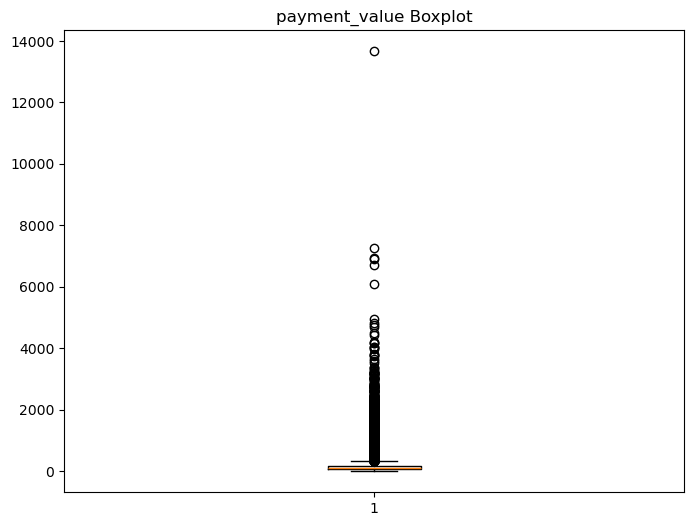

Column: payment_value
Lower bound: -110.26999999999998
Upper bound: 349.09000000000003
Number of outliers: 7908
--------------------------------------------------


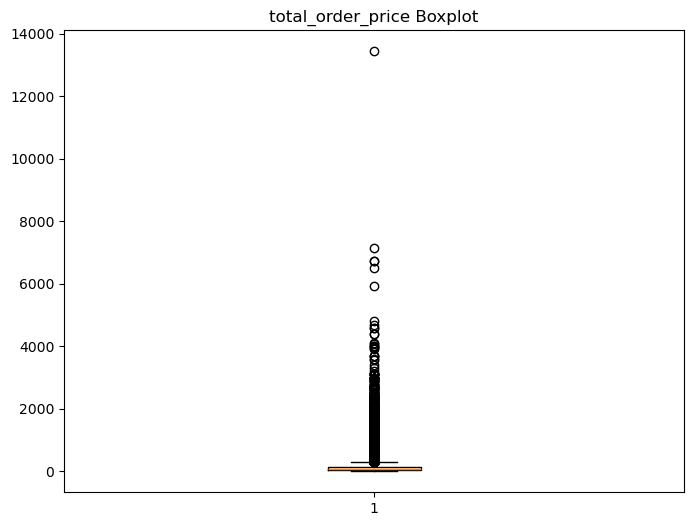

Column: total_order_price
Lower bound: -110.1
Upper bound: 305.9
Number of outliers: 7943
--------------------------------------------------


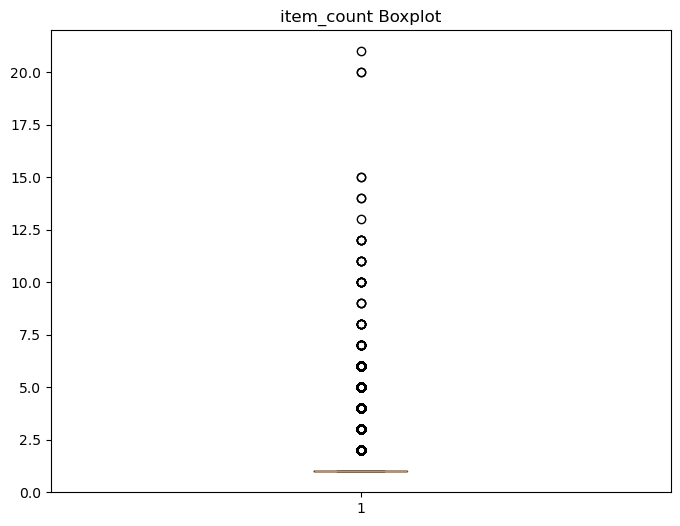

Column: item_count
Lower bound: 1.0
Upper bound: 1.0
Number of outliers: 9879
--------------------------------------------------


In [22]:


for col in numeric_cols:
    
    # boxplot
    plt.figure(figsize=(8,6))
    plt.boxplot(df[col].dropna())
    plt.title(f'{col} Boxplot')
    plt.show()
    
    # IQR calculation
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[col] < lower_bound) | (df[col] > upper_bound)
    ]
    
    print(f'Column: {col}')
    print(f'Lower bound: {lower_bound}')
    print(f'Upper bound: {upper_bound}')
    print(f'Number of outliers: {len(outliers)}')
    print('-'*50)

In [23]:
for col in numeric_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[col] < lower) | (df[col] > upper)
    ]
    
    percentage = len(outliers) / len(df) * 100
    
    print(f'{col}: {percentage:.2f}% outliers')

payment_value: 7.91% outliers
total_order_price: 7.94% outliers
item_count: 9.88% outliers


In [24]:
df = df[df['payment_value'] >= 0]

In [25]:
df['clean_text'] = (
    df['review_comment_message']
    .astype(str)
    .str.lower()
)

In [26]:
df['clean_text'] = \
df['clean_text'].apply(
    lambda x:
    re.sub(r'[^\w\s]', '', x)
)

In [27]:
df['clean_text'] = \
df['clean_text'].apply(
    lambda x:
    re.sub(r'\s+', ' ', x).strip()
)

In [28]:
df['tokens'] = \
df['clean_text'].apply(
    lambda x: x.split()
)

In [29]:
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\程诗棋\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [30]:
from nltk.corpus import stopwords



# 葡萄牙语 stopwords
portuguese_stopwords = set(
    stopwords.words('portuguese')
)

# 去除 stopwords
df['tokens'] = df['tokens'].apply(
    lambda tokens: [
        word for word in tokens
        if word.lower() not in portuguese_stopwords
    ]
)

In [31]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\程诗棋\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [32]:
df['final_text'] = df['tokens'].apply(
    lambda x: ' '.join(x)
)

In [33]:
df.to_csv(
    'final_cleaned_dataset.csv',
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
